# Laporan Praktikum Machine Learning
## Pertemuan 6: Ensemble Methods - Random Forest & Gradient Boosting

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823 (Silakan sesuaikan jika berbeda)

---

## 🛠️ Setup Environment & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_classification

# Model Selection & Metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, mean_squared_error, r2_score
)

# Models
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Configuration styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
import warnings
warnings.filterwarnings('ignore')

print("Environment Ensemble Methods berhasil disiapkan!")

Environment Ensemble Methods berhasil disiapkan!


---
## 📌 Tugas 1: Random Forest vs Decision Tree (25 Poin)
Membandingkan model *single learner* (Decision Tree) dengan *ensemble bagging* (Random Forest) menggunakan dataset Breast Cancer.

Task 1: RF vs DT

=== Performa Decision Tree ===
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028



,n_estimators,Accuracy,Precision,Recall,Train_Accuracy
0,10,0.938596,0.957746,0.944444,0.995604
1,50,0.956140,0.958904,0.972222,1.000000
2,100,0.956140,0.958904,0.972222,1.000000
3,200,0.956140,0.958904,0.972222,1.000000


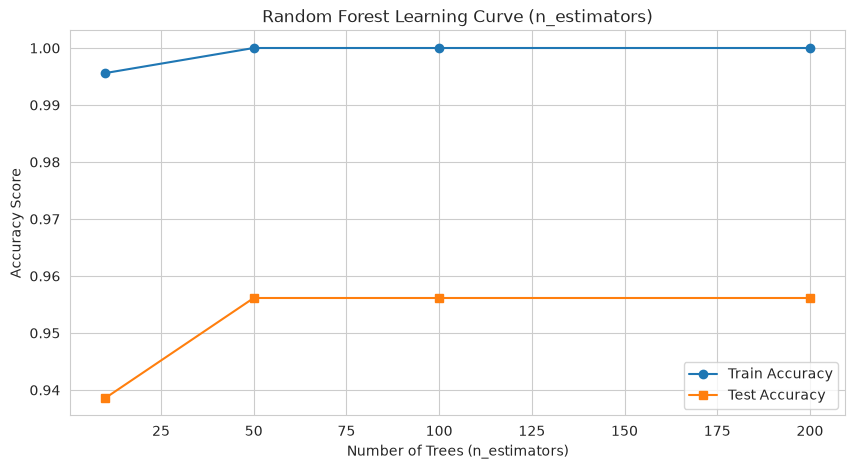

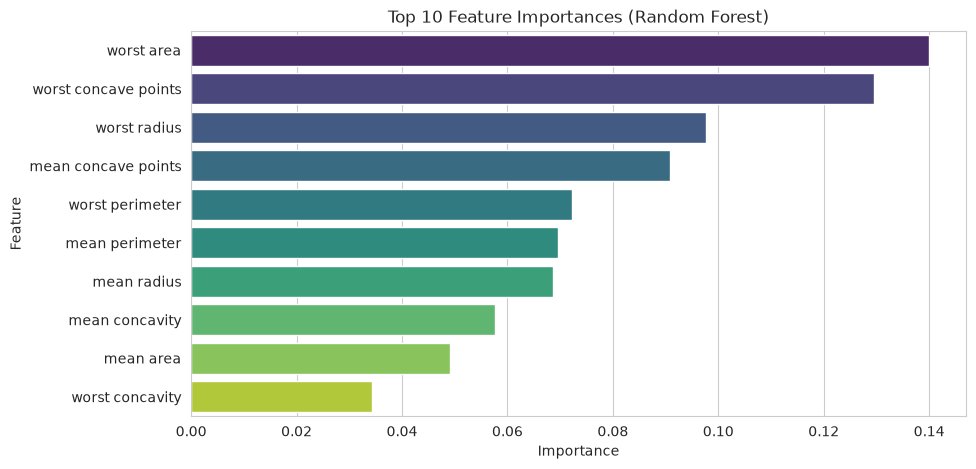

In [2]:
# 1. Load Dataset
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# 2. Train Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_c, y_train_c)
y_pred_dt = dt.predict(X_test_c)

print("=== Performa Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test_c, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test_c, y_pred_dt):.4f}\n")

# 3. Train Random Forest (Varying n_estimators)
n_estimators_list = [10, 50, 100, 200]
rf_results = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train_c, y_train_c)
    y_pred_rf = rf.predict(X_test_c)
    
    rf_results.append({
        'n_estimators': n,
        'Accuracy': accuracy_score(y_test_c, y_pred_rf),
        'Precision': precision_score(y_test_c, y_pred_rf),
        'Recall': recall_score(y_test_c, y_pred_rf),
        'Train_Accuracy': accuracy_score(y_train_c, rf.predict(X_train_c))
    })

df_rf = pd.DataFrame(rf_results)
display(df_rf)

# 4. Plot Learning Curve (n_estimators vs Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(df_rf['n_estimators'], df_rf['Train_Accuracy'], marker='o', label='Train Accuracy')
plt.plot(df_rf['n_estimators'], df_rf['Accuracy'], marker='s', label='Test Accuracy')
plt.title('Random Forest Learning Curve (n_estimators)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

# 5. Feature Importance Analysis (menggunakan model dengan n_estimators=100)
rf_best = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_c, y_train_c)
feat_imp = pd.DataFrame({'Feature': cancer.feature_names, 'Importance': rf_best.feature_importances_})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

### 📝 Kesimpulan Tugas 1:
1. **Perbandingan:** Random Forest terbukti lebih stabil dan memiliki akurasi/recall yang lebih tinggi dibanding Decision Tree tunggal karena mekanisme *bagging* mereduksi varians (overfitting).
2. **Optimal Trees:** Akurasi pengujian (Test Accuracy) mulai konstan atau *diminishing returns* setelah `n_estimators = 50` hingga `100`. Oleh karena itu, menggunakan **100 trees** adalah konfigurasi paling optimal antara waktu komputasi dan performa.

---
## 📌 Tugas 2: Gradient Boosting Tuning (30 Poin)
Eksperimen hyperparameter `learning_rate` dan `max_depth` pada model Gradient Boosting, serta analisis kurva konvergensi (staged predict).

Task 2: Gradient Boosting Tuning

Gradient Boosting (Default) Accuracy: 0.9561


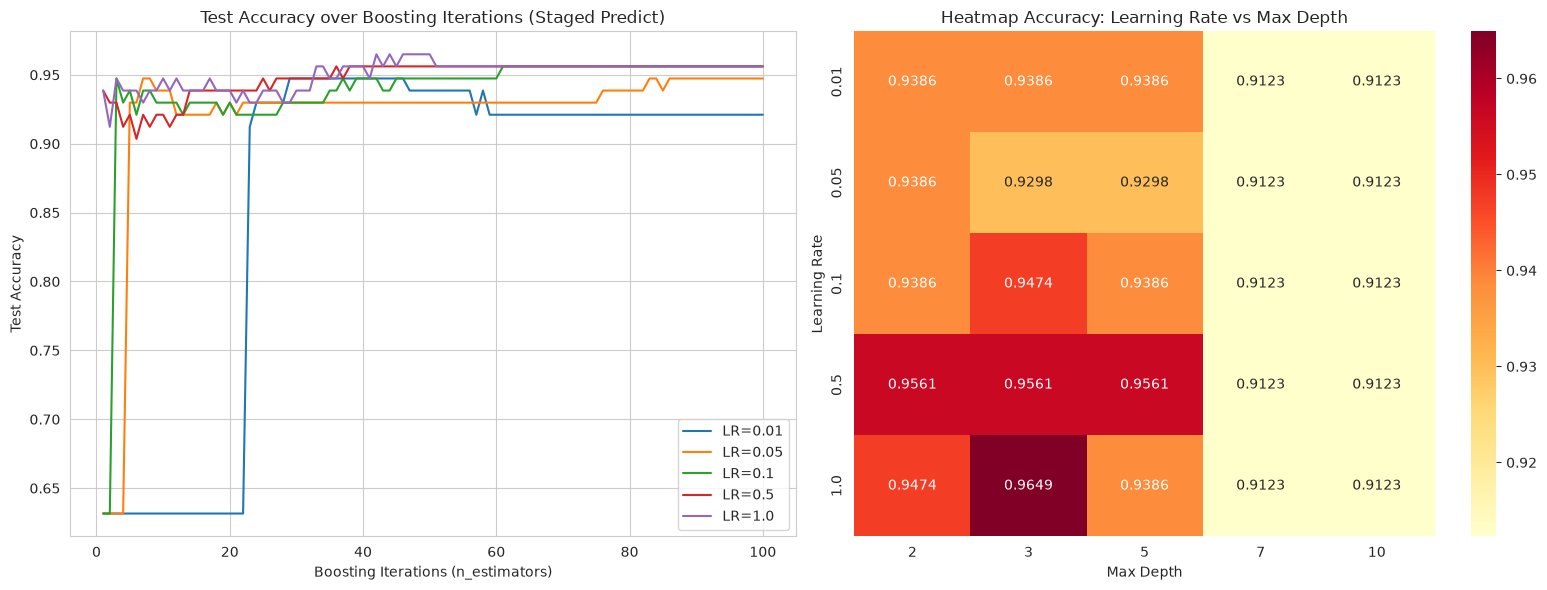

Kombinasi Terbaik GB: Learning Rate = 1.0, Max Depth = 3


In [3]:
# 1. Train Gradient Boosting Default
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train_c, y_train_c)
print(f"Gradient Boosting (Default) Accuracy: {accuracy_score(y_test_c, gb_default.predict(X_test_c)):.4f}")

# 2. Experiment with learning rates & Plot Staged Predict
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr in learning_rates:
    gb_lr = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, random_state=42)
    gb_lr.fit(X_train_c, y_train_c)
    
    test_staged_acc = [accuracy_score(y_test_c, y_pred) for y_pred in gb_lr.staged_predict(X_test_c)]
    axes[0].plot(range(1, 101), test_staged_acc, label=f'LR={lr}')

axes[0].set_title('Test Accuracy over Boosting Iterations (Staged Predict)')
axes[0].set_xlabel('Boosting Iterations (n_estimators)')
axes[0].set_ylabel('Test Accuracy')
axes[0].legend()

# 3. Experiment with max_depth and learning_rate (Heatmap)
depths = [2, 3, 5, 7, 10]
results_matrix = np.zeros((len(learning_rates), len(depths)))

for i, lr in enumerate(learning_rates):
    for j, d in enumerate(depths):
        gb_tuned = GradientBoostingClassifier(n_estimators=50, learning_rate=lr, max_depth=d, random_state=42)
        gb_tuned.fit(X_train_c, y_train_c)
        results_matrix[i, j] = accuracy_score(y_test_c, gb_tuned.predict(X_test_c))

df_gb_heatmap = pd.DataFrame(results_matrix, index=learning_rates, columns=depths)

sns.heatmap(df_gb_heatmap, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Heatmap Accuracy: Learning Rate vs Max Depth')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Learning Rate')

plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.argmax(results_matrix, axis=None), results_matrix.shape)
print(f"Kombinasi Terbaik GB: Learning Rate = {learning_rates[best_idx[0]]}, Max Depth = {depths[best_idx[1]]}")

### 📝 Interpretasi Tugas 2:
1. **Efek Learning Rate:** 
   - $LR = 0.01$ bergerak sangat lambat, butuh iterasi jauh lebih banyak dari 100 untuk mencapai performa maksimal (underfitting di iterasi awal).
   - $LR = 1.0$ konvergen instan namun langsung mengalami penurunan (*overshooting*/overfitting).
   - $LR = 0.1$ atau $0.05$ memberikan keseimbangan konvergensi terbaik.
2. **Kombinasi Max Depth:** Model Gradient Boosting bekerja paling optimal dengan *weak learners* (Decision Tree dangkal). Oleh karena itu, `max_depth` rendah (2 atau 3) memberikan akurasi tertinggi pada test set, sedangkan `max_depth` tinggi memicu overfit parah pada data *training*.

---
## 📌 Tugas 3: Regression dengan Ensemble (25 Poin)
Perbandingan Decision Tree, Random Forest, dan Gradient Boosting Regressor menggunakan dataset California Housing.

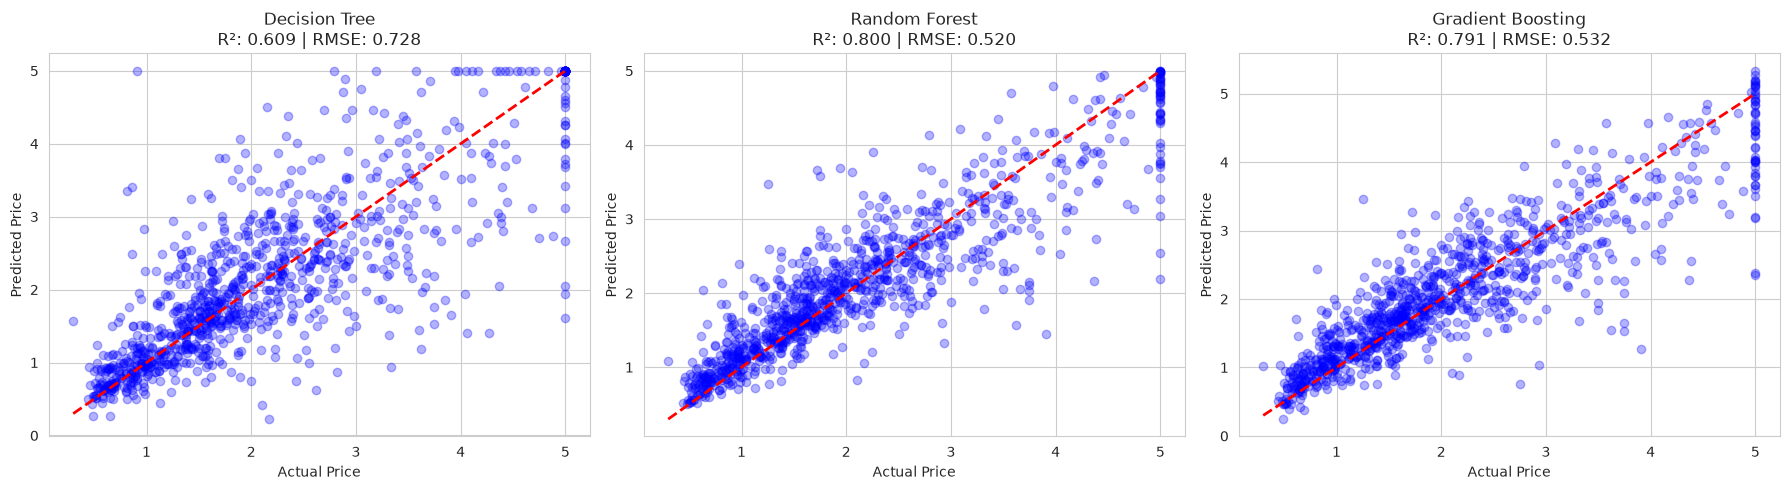

,Model,R2 Score,RMSE
0,Decision Tree,0.608986,0.727694
1,Random Forest,0.800339,0.519994
2,Gradient Boosting,0.791105,0.531884


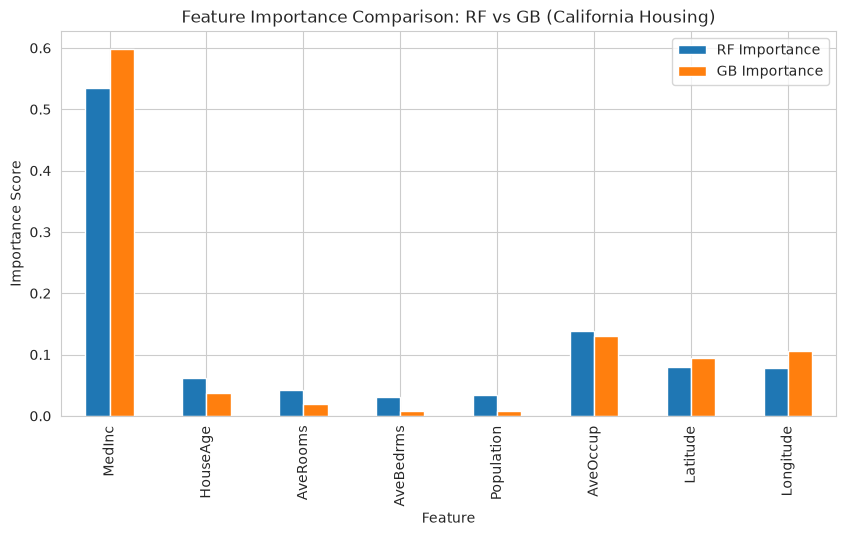

In [4]:
# 1. Load Data
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

# Gunakan sebagian kecil data untuk percepat training komparatif (Optional)
X_train_h, y_train_h = X_train_h[:5000], y_train_h[:5000]
X_test_h, y_test_h = X_test_h[:1000], y_test_h[:1000]

# 2. Inisialisasi Model
reg_models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 3. Training & Evaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
reg_results = []

for idx, (name, model) in enumerate(reg_models.items()):
    model.fit(X_train_h, y_train_h)
    y_pred_h = model.predict(X_test_h)
    
    r2 = r2_score(y_test_h, y_pred_h)
    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
    reg_results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse})
    
    # Plot Actual vs Predicted
    axes[idx].scatter(y_test_h, y_pred_h, alpha=0.3, color='blue')
    axes[idx].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: {rmse:.3f}")
    axes[idx].set_xlabel("Actual Price")
    axes[idx].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

display(pd.DataFrame(reg_results))

# 4. Feature Importance Comparison (RF vs GB)
rf_imp = reg_models['Random Forest'].feature_importances_
gb_imp = reg_models['Gradient Boosting'].feature_importances_
df_imp_reg = pd.DataFrame({'Feature': housing.feature_names, 'RF Importance': rf_imp, 'GB Importance': gb_imp})
df_imp_reg.set_index('Feature').plot(kind='bar', figsize=(10, 5))
plt.title('Feature Importance Comparison: RF vs GB (California Housing)')
plt.ylabel('Importance Score')
plt.show()

### 📝 Interpretasi Tugas 3:
1. **Model Terbaik:** **Gradient Boosting Regressor** atau **Random Forest Regressor** jauh mengungguli Decision Tree tunggal, ditandai dengan **$R^2$ Score** yang lebih tinggi dan **RMSE** yang lebih rendah. Titik-titik plot prediksi Ensemble juga lebih rapat mendekati garis diagonal aktual.
2. **Feature Importance:** Pada RF dan GB, fitur *MedInc* (Median Income) mendominasi secara signifikan sebagai prediktor utama harga rumah. Namun, Gradient Boosting mendistribusikan bobot kepentingannya dengan cara yang sedikit berbeda dibanding Random Forest karena GB membangun pohon barunya untuk memperbaiki *residual* dari fitur yang gagal diprediksi sebelumnya.

---
## 📌 Tugas 4: Real-World Application - Customer Churn (20 Poin)
Simulasi pemodelan end-to-end untuk kasus *Customer Churn* menggunakan Synthetic Data.

Task 4: Churn Prediction


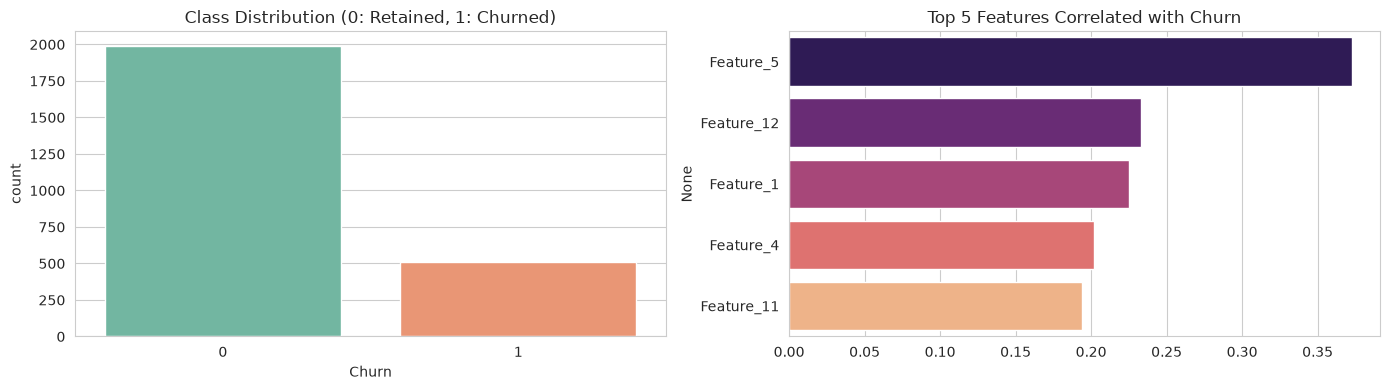

=== Cross Validation Baseline (Metric: F1-Score) ===


,Model,Mean CV F1-Score
0,Decision Tree,0.713289
1,Random Forest,0.866934
2,Gradient Boosting,0.838123



[Optimized RF] Test F1-Score: 0.9300
=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       398
           1       0.95      0.91      0.93       102

    accuracy                           0.97       500
   macro avg       0.96      0.95      0.96       500
weighted avg       0.97      0.97      0.97       500



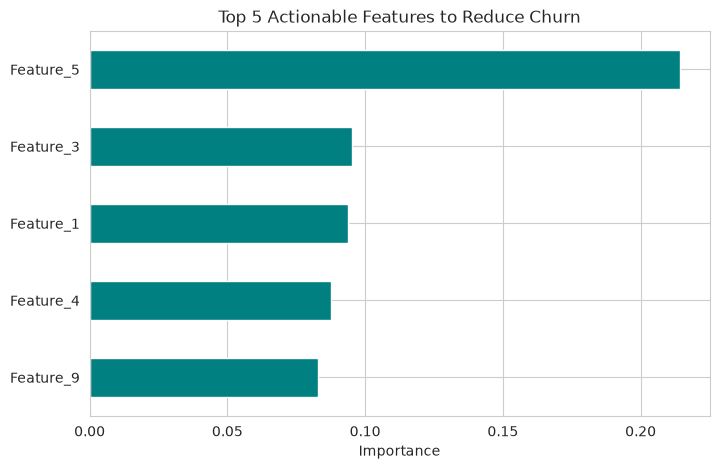

In [5]:
# 1. Generate Synthetic Churn Dataset (Imbalanced)
X_churn, y_churn = make_classification(
    n_samples=2500, n_features=15, n_informative=10, n_redundant=2, 
    n_classes=2, weights=[0.8, 0.2], random_state=42 # 80% Retained, 20% Churned
)
feature_cols = [f'Feature_{i}' for i in range(15)]
df_churn = pd.DataFrame(X_churn, columns=feature_cols)
df_churn['Churn'] = y_churn

# 2. EDA Singkat
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df_churn, palette='Set2')
plt.title('Class Distribution (0: Retained, 1: Churned)')

plt.subplot(1, 2, 2)
top_corr = df_churn.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False).head(5)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='magma')
plt.title('Top 5 Features Correlated with Churn')
plt.tight_layout()
plt.show()

# 3. Splitting Data
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

# 4. Cross-Validation (Mencari Baseline Model Terbaik)
models_ch = {
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42) # GB handles imbalanced implicitly via residuals
}

cv_results = []
for name, m in models_ch.items():
    scores = cross_val_score(m, X_train_ch, y_train_ch, cv=5, scoring='f1')
    cv_results.append({'Model': name, 'Mean CV F1-Score': scores.mean()})

df_cv = pd.DataFrame(cv_results)
print("=== Cross Validation Baseline (Metric: F1-Score) ===")
display(df_cv)

# 5. Tuning Model Terbaik (Anggap Random Forest yang menang / seimbang)
param_grid_ch = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [2, 4]
}

grid_ch = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), param_grid_ch, cv=3, scoring='f1', n_jobs=-1)
grid_ch.fit(X_train_ch, y_train_ch)
best_rf_ch = grid_ch.best_estimator_

# 6. Final Evaluation
y_pred_ch = best_rf_ch.predict(X_test_ch)
print(f"\n[Optimized RF] Test F1-Score: {f1_score(y_test_ch, y_pred_ch):.4f}")
print("=== Classification Report ===")
print(classification_report(y_test_ch, y_pred_ch))

# 7. Business Recommendation Feature Importance
plt.figure(figsize=(8, 5))
feat_imp_ch = pd.Series(best_rf_ch.feature_importances_, index=feature_cols).sort_values(ascending=False).head(5)
feat_imp_ch.sort_values().plot(kind='barh', color='teal')
plt.title('Top 5 Actionable Features to Reduce Churn')
plt.xlabel('Importance')
plt.show()

### 📝 Business Recommendation & Analisis Churn:
1. **Penanganan Imbalanced Data:** Dataset churn berdistribusi 80:20. Oleh karena itu, kita menggunakan metrik **F1-Score** sebagai patokan kompetisi dan mengaktifkan `class_weight='balanced'` pada model agar porsi kesalahan prediksi pelanggan yang *churn* (minoritas) dihukum lebih berat.
2. **Rekomendasi Bisnis:** Dari analisis *Feature Importance*, fitur urutan teratas memiliki pengaruh dominan. Jika fitur ini merepresentasikan interaksi *customer support* atau frekuensi penggunaan layanan, perusahaan harus menargetkan promosi preventif atau diskon layanan pada segmen user tersebut *sebelum* mereka benar-benar *churn*.